In [51]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
import random
import matplotlib.pyplot as plt
from model.network import Network
from util.data_loader import DataLoader
from util.checkpoint_manager import CheckpointManager
from util.adamw import AdamWOptimizer
from util.evaluation_helper import EvaluationHelper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [25]:
data_loader = DataLoader("input/training.txt", "input/validation.txt", num_merges=400)
vocabulary = data_loader.get_vocabulary()

Training BPE with 400 merges...
  merge 100/400: 'i'+'t ' -> 'it '  (vocab=165)
  merge 200/400: 'E'+'R' -> 'ER'  (vocab=265)
  merge 300/400: 'd'+'er' -> 'der'  (vocab=364)
  merge 400/400: 'st'+'er' -> 'ster'  (vocab=462)
Training data length: X=398132, Y=398132
Validation data length: X=106279, Y=106279
Vocabulary size: 462


In [26]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

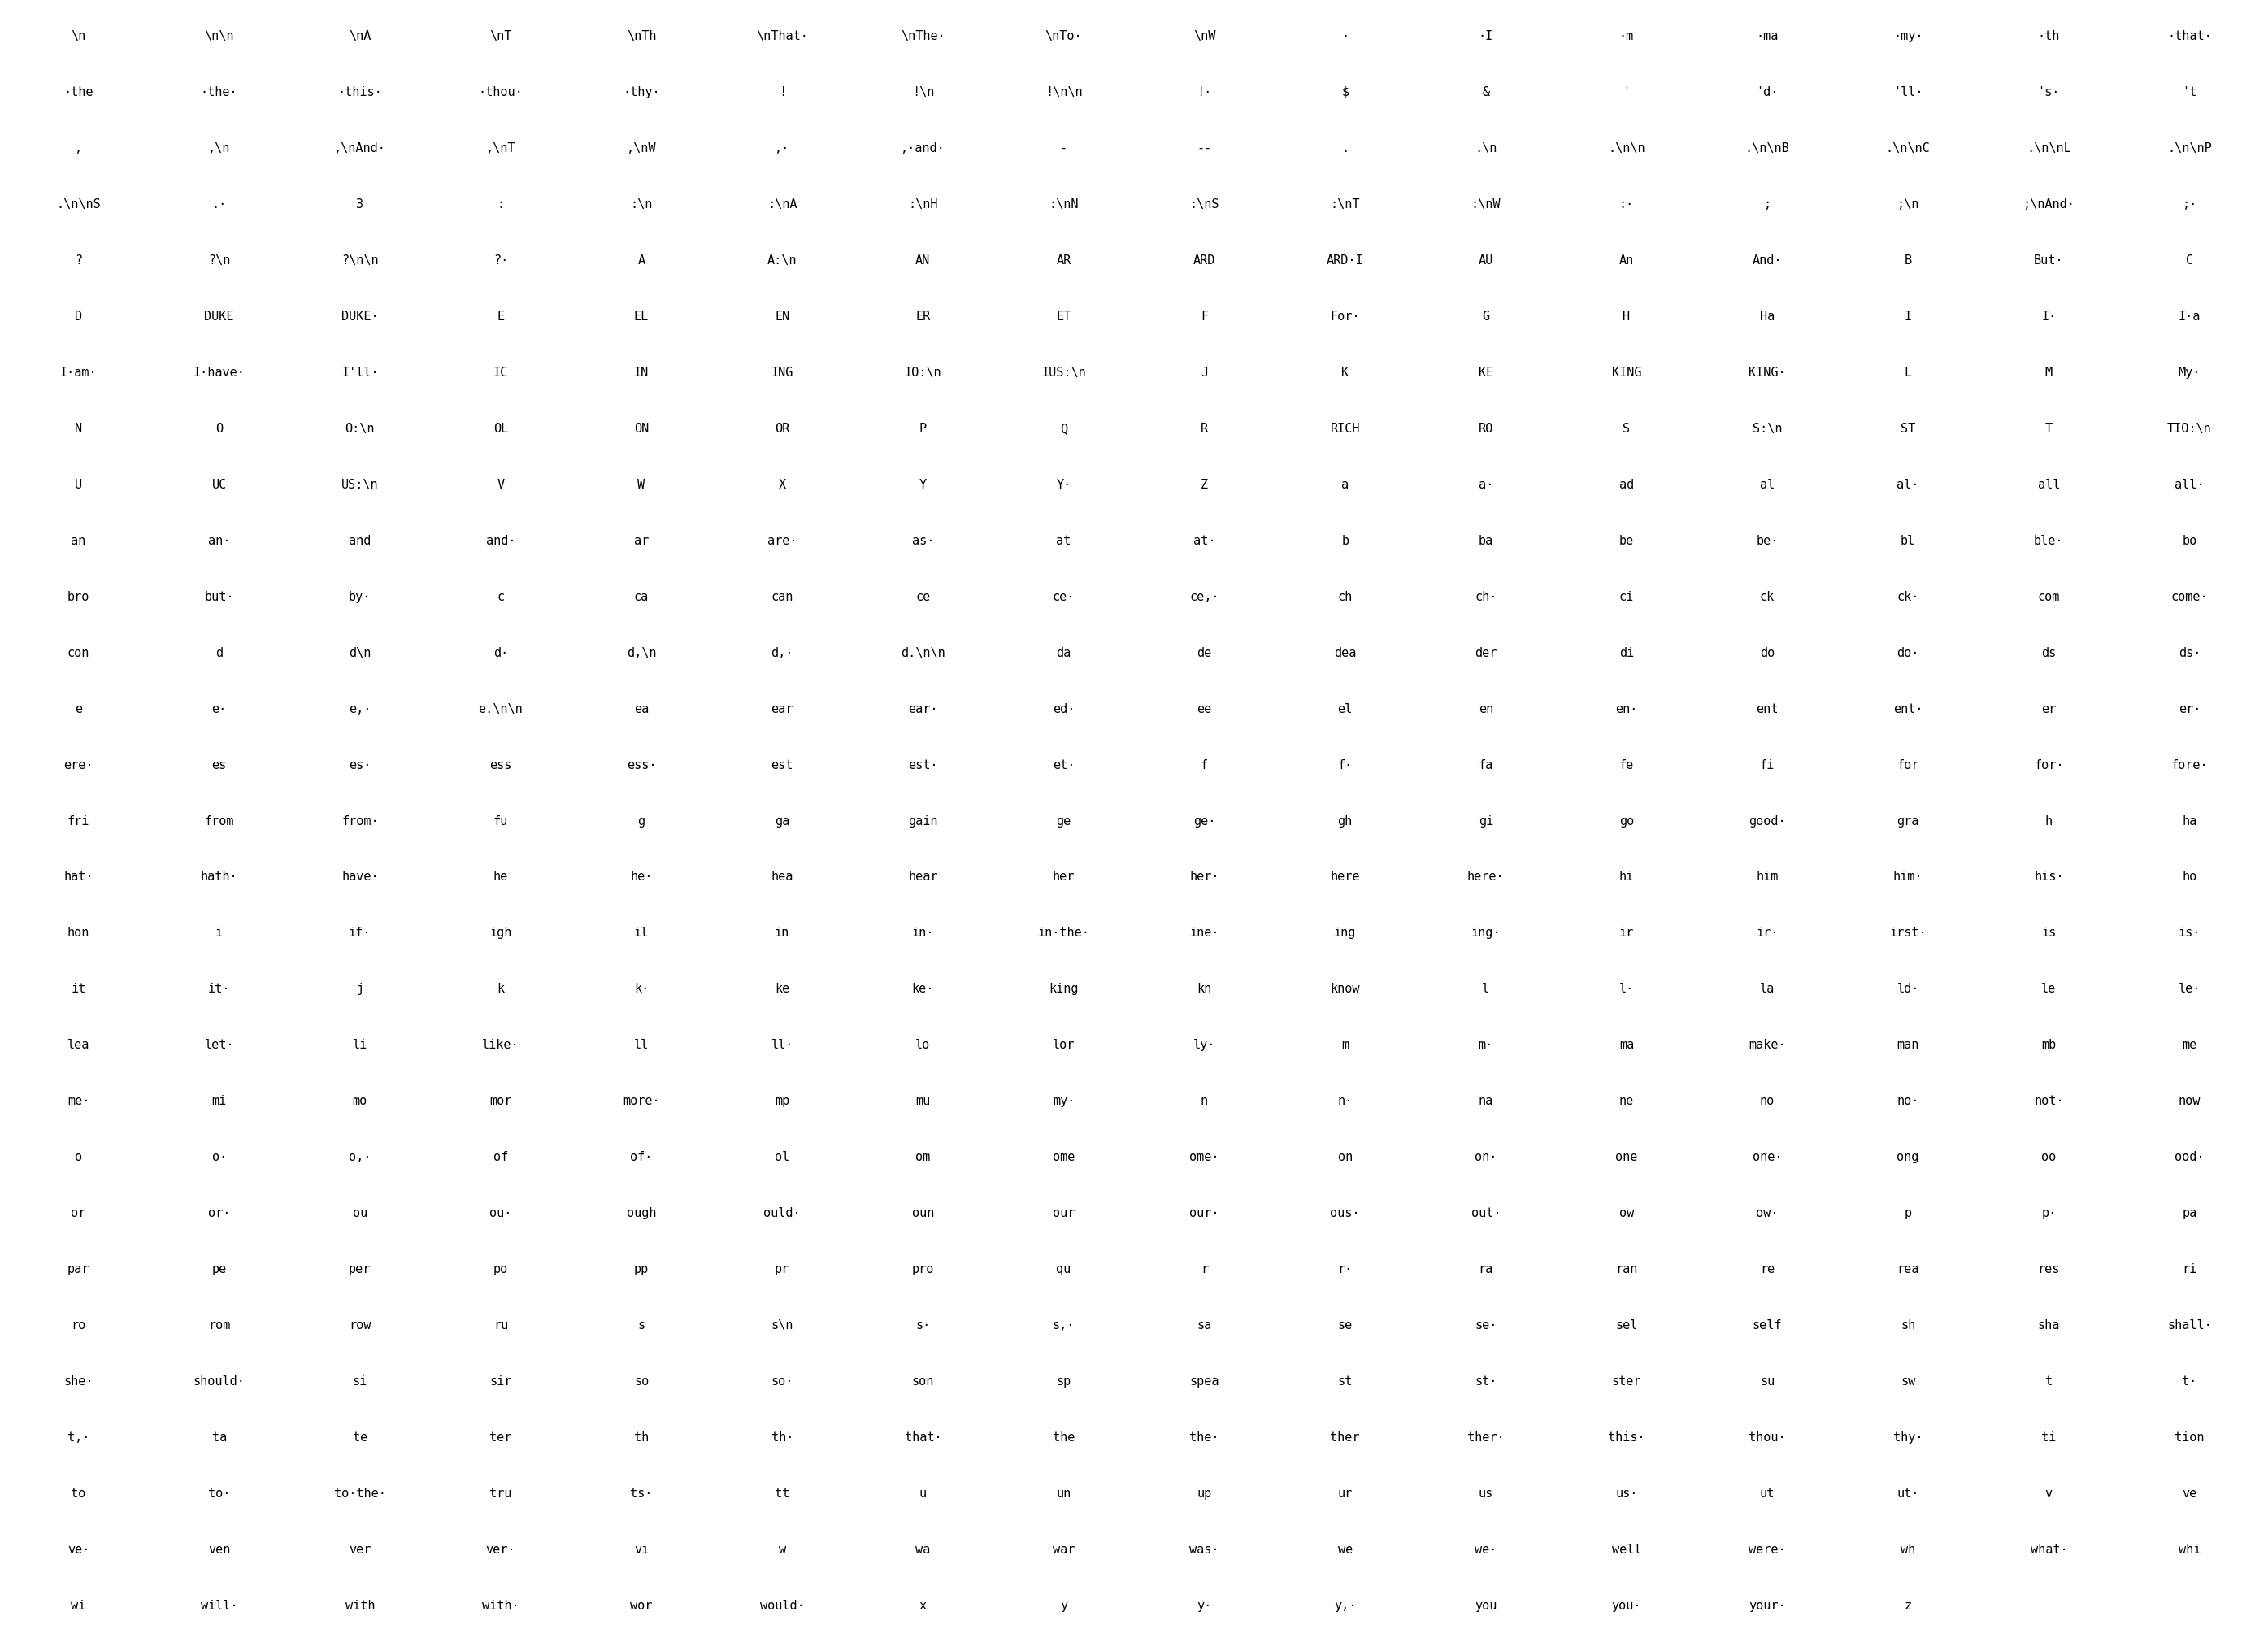

In [27]:
data_loader.plot_vocabulary()

In [28]:
x_train_indices, y_train_indices, x_test_indices, y_test_indices = data_loader.get_indices()

## Building the Model

In [29]:
embedding_dim = 128
hidden_size = 256
hidden2_size = 192

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "LSTM", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout"},
    {"type": "LSTM", "input_size": hidden_size, "num_neurons": hidden2_size},
    {"type": "Dropout"},
    {"type": "Softmax", "input_size": hidden2_size, "num_neurons": len(vocabulary)},
]

model = Network(layer_definitions=layer_definitions)
model.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (462, 128)
  Parameters: 59,136

Layer 2: LSTMLayer
  Weights Shape: (128, 256) | Recurrent Weights Shape: (256, 256) | Gates: 4
  Parameters: 394,240

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: LSTMLayer
  Weights Shape: (256, 192) | Recurrent Weights Shape: (192, 192) | Gates: 4
  Parameters: 344,832

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (192, 462) | Biases Shape: (462,)
  Parameters: 89,166

Total Parameters: 887,374


## Training the Model

In [30]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [31]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [32]:
def evaluate(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = model.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(model.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            model.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)

In [33]:
def train_epoch(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    optimizer: AdamWOptimizer,
    max_steps: int | None = None,
    clip_value: float | None = None,
) -> float:
    model.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = model.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(model.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        model.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        optimizer.step(model, learning_rate)
        model.reset_states(batch_size=batch_size, dtype=cp.float32)

    model.set_training(False)
    return math.exp(total_loss / total_steps)


In [34]:
hyperparameters = {
    "sequence_length": 128,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 1e-3,
    "min_learning_rate": 1e-5,
    "weight_decay_lambda": 1e-2,
    "beta1": 0.9,
    "beta2": 0.999,
    "epsilon": 1e-8,
    "early_stopping_patience": 50,
    "clip_value": 5.0,
    "checkpoint_interval": 50,
    "dropout_rate": 0.3
}

print(hyperparameters)

{'sequence_length': 128, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 0.001, 'min_learning_rate': 1e-05, 'weight_decay_lambda': 0.01, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08, 'early_stopping_patience': 50, 'clip_value': 5.0, 'checkpoint_interval': 50, 'dropout_rate': 0.3}


In [35]:
checkpoint_manager = CheckpointManager(file_name="lstm_checkpoint.pkl")
best_model, epoch_summaries, best_perplexity = checkpoint_manager.load_checkpoint()

if best_model is not None:
    model = best_model.clone()

optimizer = AdamWOptimizer(
    beta1=hyperparameters["beta1"],
    beta2=hyperparameters["beta2"],
    epsilon=hyperparameters["epsilon"],
    weight_decay=hyperparameters["weight_decay_lambda"],
)

max_available_steps = int(x_train_indices.shape[0]) // hyperparameters["batch_size"]
train_steps_per_epoch = min(hyperparameters["train_steps_per_epoch"], max_available_steps)
if train_steps_per_epoch < hyperparameters["train_steps_per_epoch"]:
    print(f"Warning: train_steps_per_epoch clamped from {hyperparameters['train_steps_per_epoch']} to {train_steps_per_epoch} (data too short after BPE compression)")

model.update_dropout_rate(hyperparameters["dropout_rate"])

epoch_offset = len(epoch_summaries)
total_steps = (epoch_offset + hyperparameters["epochs"]) * train_steps_per_epoch
global_step = epoch_offset * train_steps_per_epoch
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * train_steps_per_epoch
max_offset = int(x_train_indices.shape[0]) - slice_size


Loaded checkpoint, best perplexity: 26.8136


In [36]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        model=model,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        optimizer=optimizer,
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        model=model,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = model.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break


{'epoch': 863, 'learning_rate': 0.0005624967154853965, 'train_perplexity': 24.556324970614945, 'test_perplexity': 26.760645598778286, 'regularization': 0.9176282717086626}
{'epoch': 870, 'learning_rate': 0.0005566862159352671, 'train_perplexity': 24.001612567907348, 'test_perplexity': 26.406165725799628, 'regularization': 0.9089397081400971}
{'epoch': 880, 'learning_rate': 0.0005483731970528423, 'train_perplexity': 23.681926356920293, 'test_perplexity': 26.22319851196998, 'regularization': 0.9030906869011542}
{'epoch': 890, 'learning_rate': 0.000540047831452533, 'train_perplexity': 24.392541917307476, 'test_perplexity': 26.002229423071014, 'regularization': 0.9380942503208856}
{'epoch': 900, 'learning_rate': 0.0005317124890527988, 'train_perplexity': 23.3991010062973, 'test_perplexity': 25.96582675190024, 'regularization': 0.9011498547638156}
  Checkpoint saved -> checkpoints\lstm_checkpoint.pkl
{'epoch': 910, 'learning_rate': 0.0005233695426121193, 'train_perplexity': 23.3535315905870

In [37]:
print(f"Best validation perplexity: {best_perplexity:.6f}")
checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

Best validation perplexity: 25.703930
  Checkpoint saved -> checkpoints\lstm_checkpoint.pkl


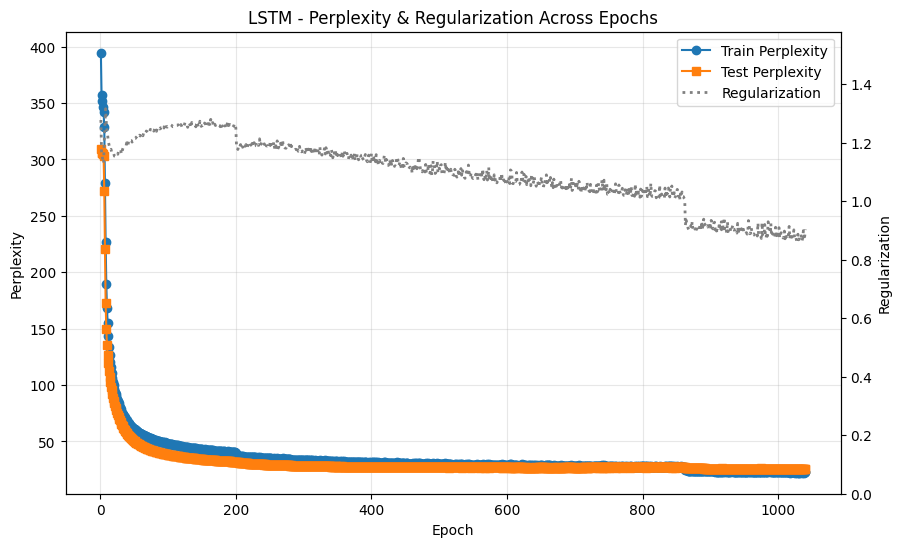

In [38]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("LSTM - Perplexity & Regularization Across Epochs")
plt.show()

## Evaluating the Model

### Text Generation

In [52]:
eval_helper = EvaluationHelper(model=best_model, data_loader=data_loader, vocabulary=vocabulary)
generated_tokens = eval_helper.generate_text(seed_text="HAMLET", length=500, temperature=0.7)

HAMLET:
I do not be your projust, and I'll have you love,
I can you, I should besish the froths deed
To give him go.

KING EDWARD IV:
Because you are to hence with a flatterer.

Third Citizen:
From pay the body of the duke of pain
And prococks and find of the voice so hate
To bear the praiming from the lust hear
And though you precious up to drend.

GLOUCESTER:
Then, traunty; and breaks me all my lady?

CAPULET:
Methinks Diar still, depure, thy quenres
Bectornage, I would to be great a duke,
Hy's change my lord's courses, deed of love.
But my grandsals, I will put it against him
discacs your lord of bucked but bitt
That sworn with the morning, the master is quickly,
Comtree to my father's both to meet.

KING RICHARD III:
I know him for your word of the plain.
What is the countory! I would not speak to be so
Put all the bring of mine eyes with sin.
You cannot seek deem of affectree,
Since that I know to thee. Here back, I will be
look thee, but never caice to hence on the goods
As then,

### Token Frequencies

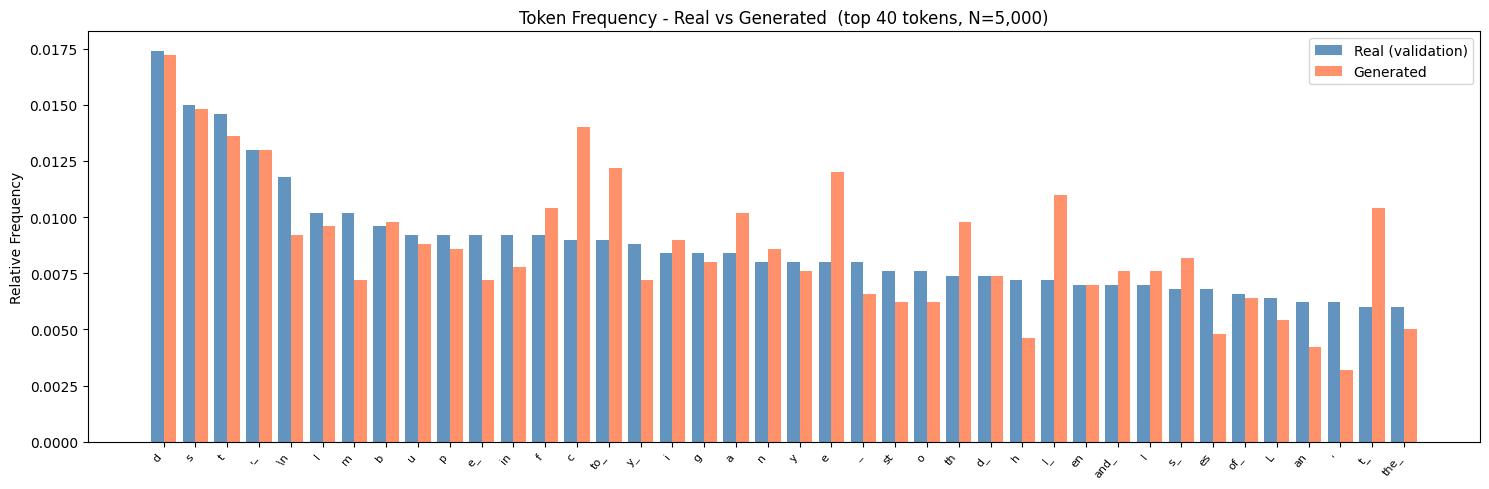

In [53]:
eval_helper.plot_token_frequencies(x_test_indices=x_test_indices)

### Embedding Spaces

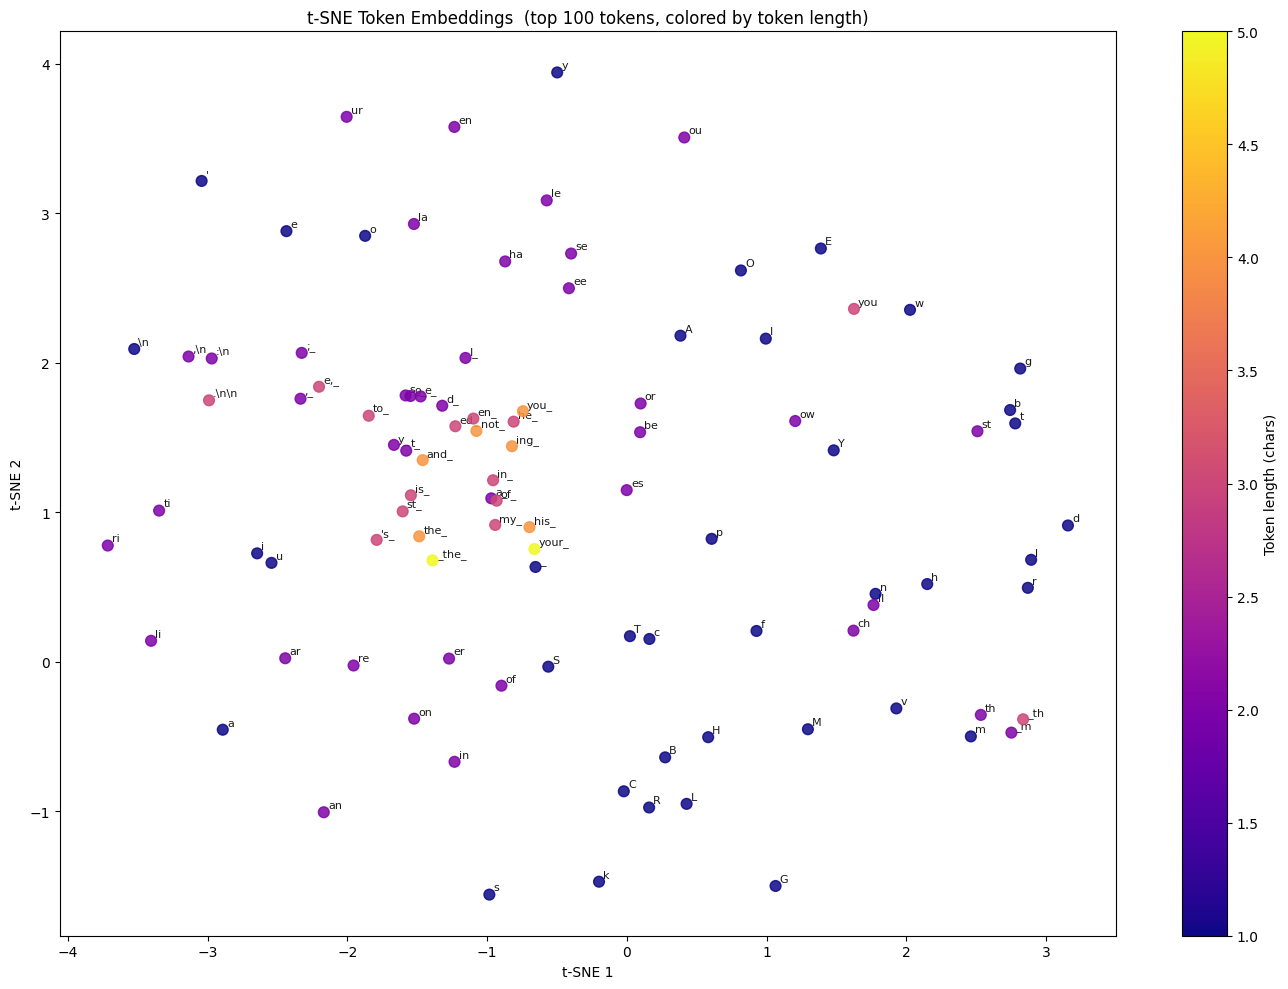

In [55]:
eval_helper.plot_embeddings_tsne(x_test_indices=x_test_indices)

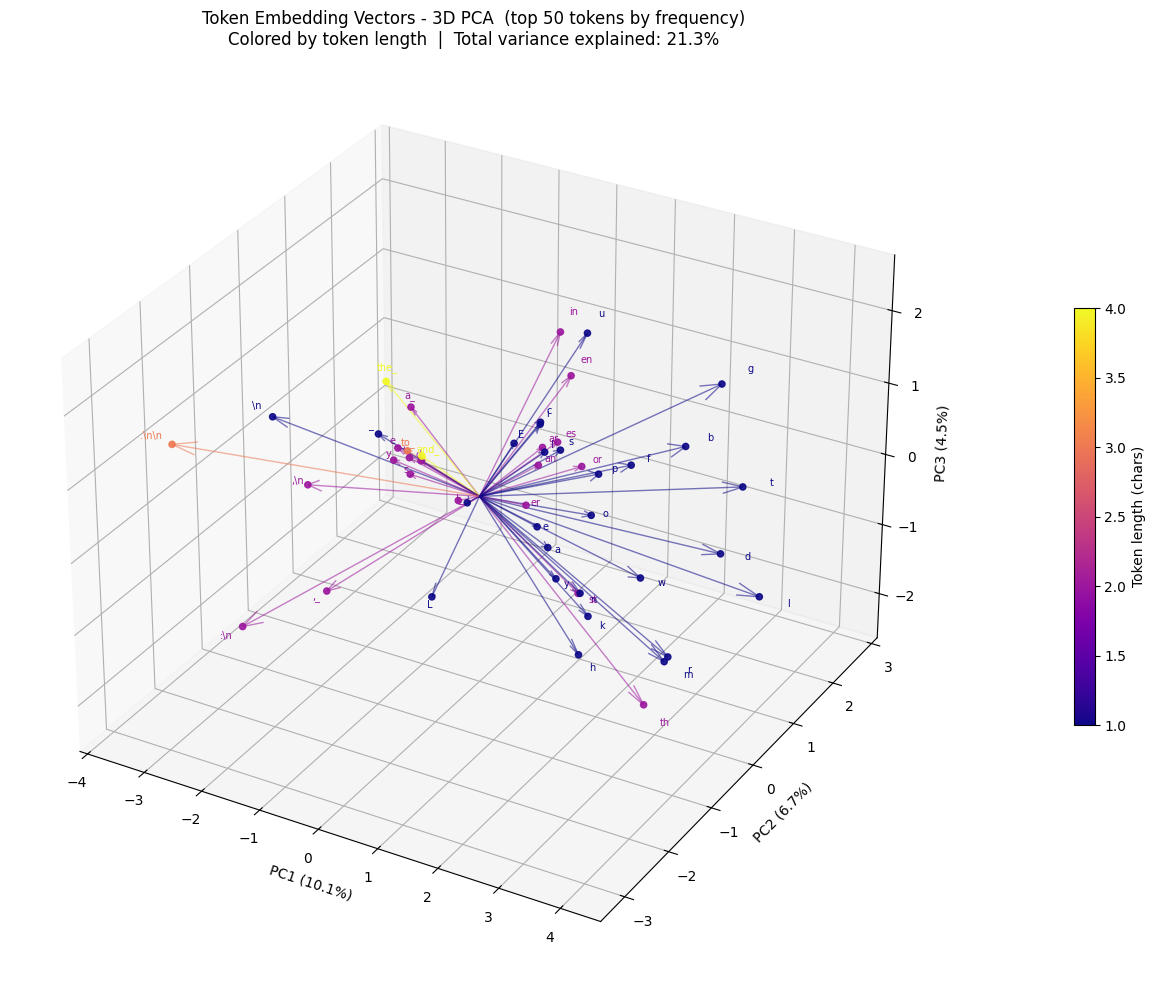

In [56]:
eval_helper.plot_embeddings_3d(x_test_indices=x_test_indices)

### Hidden State Trajectory

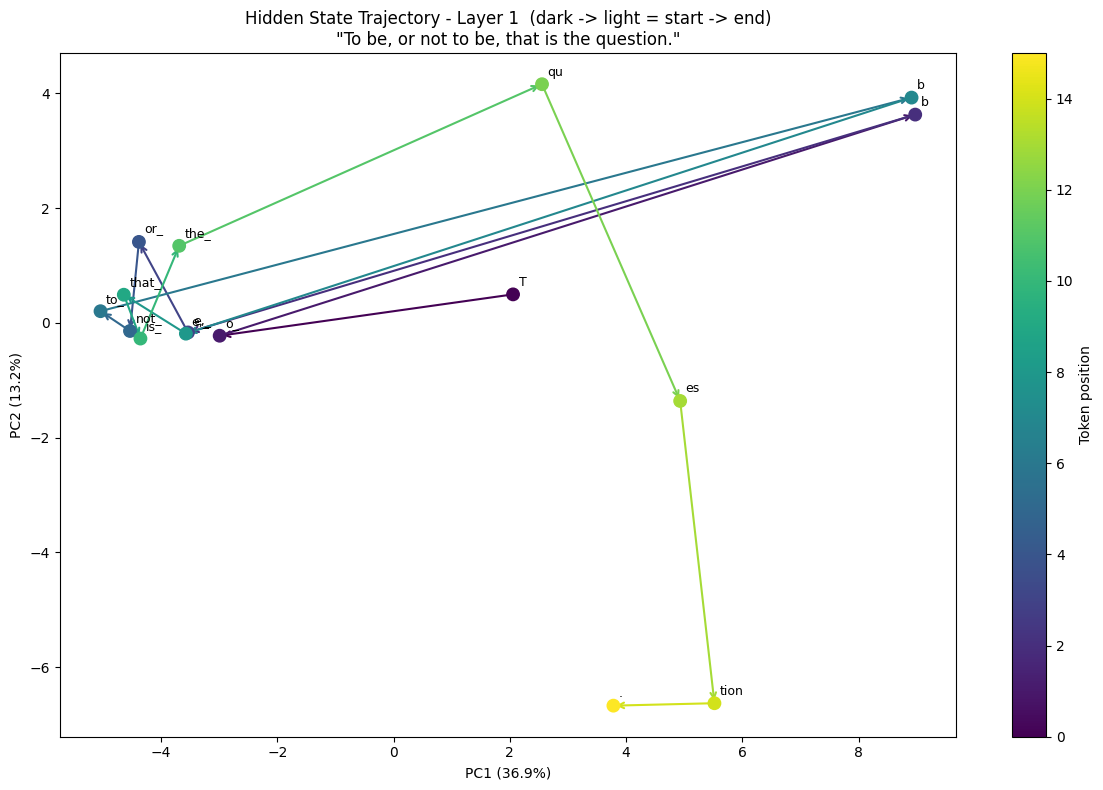

In [57]:
eval_helper.plot_hidden_state_trajectory(sentence="To be, or not to be, that is the question.")

### Temperature Sweep

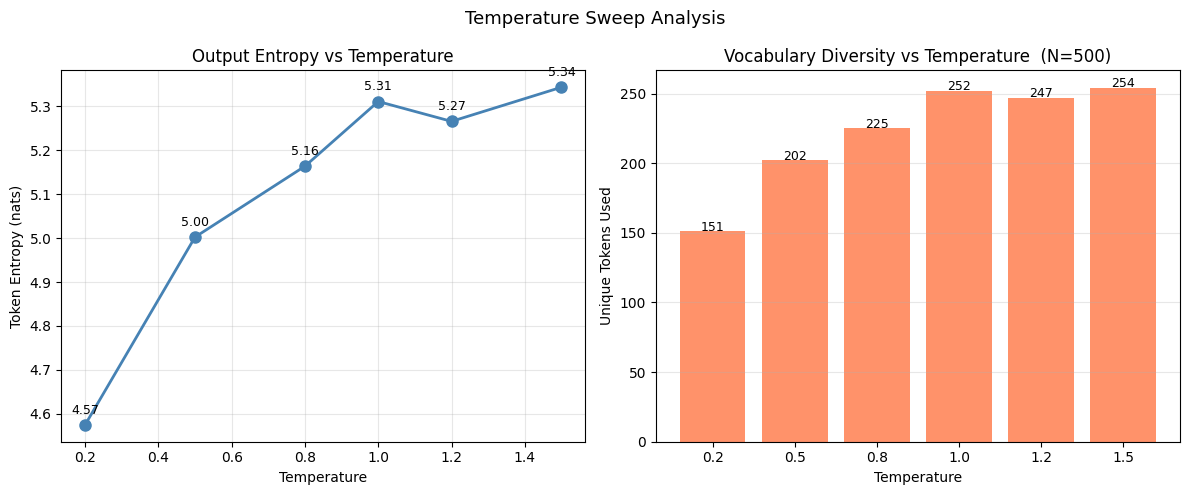

In [58]:
eval_helper.plot_temperature_sweep(seed_text="HAMLET")